In [2]:
#Lab 3.4 — CNN Applications: Classification, Detection, Segmentation
#1. Image Classification with ResNet
# Import libraries
import torch
import PIL.Image as Image
from torchvision import transforms, models

# Load pretrained ResNet model
model = models.resnet18(pretrained=True)
model.eval()

# Define transforms
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load image
img = Image.open("Sample.jpg").convert("RGB")

# Apply transforms
x = tfm(img).unsqueeze(0)

# Prediction
with torch.no_grad():
    out = model(x)

pred = out.argmax(1).item()

print("Predicted class:", pred)

C:\Users\Mash ALLAH Com\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Mash ALLAH Com\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Predicted class: 719


In [3]:
#2. Object Detection (Faster R-CNN)
det = models.detection.fasterrcnn_resnet50_fpn(pretrained=True).eval()
detections = det(x)
print(detections[0])

C:\Users\Mash ALLAH Com\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Mash ALLAH Com/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|███████████████████████████████████████████████████████████████████████████████| 160M/160M [01:24<00:00, 1.98MB/s]


{'boxes': tensor([[  3.9750,  15.1710, 222.3928, 129.0907],
        [  0.0000,  36.6829, 224.0000, 215.5089],
        [151.5130, 205.4718, 156.6877, 211.8520],
        [ 48.4504,  95.8601,  64.8551, 107.6862]], grad_fn=<StackBackward0>), 'labels': tensor([ 3,  3, 37, 85]), 'scores': tensor([0.1113, 0.0996, 0.0683, 0.0553], grad_fn=<IndexBackward0>)}


C:\Users\Mash ALLAH Com\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Mash ALLAH Com\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


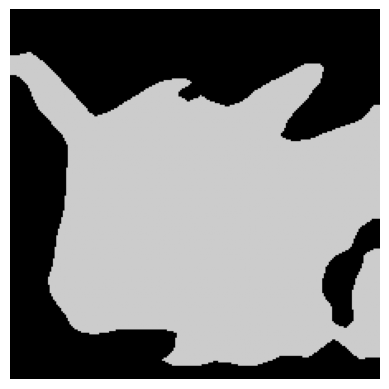

In [5]:
#3. Semantic Segmentation (DeepLabV3)
import torch
import matplotlib.pyplot as plt
from torchvision import models

# Load model
seg = models.segmentation.deeplabv3_resnet50(pretrained=True).eval()

# Run inference
with torch.no_grad():
    output = seg(x)

# Get mask
mask = output['out'][0].argmax(0)

# Show result
plt.imshow(mask.detach().cpu(), cmap="nipy_spectral")
plt.axis("off")
plt.show()